In [29]:
import keras
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix
from sklearn.impute import SimpleImputer
from keras import Sequential
from keras.layers import Dense, BatchNormalization, Input, Dropout
from keras.callbacks import EarlyStopping
import kagglehub

## Leitura dos Dados

In [2]:
path = kagglehub.competition_download('playground-series-s6e8')
print("Path to competition files:", path)

Path to competition files: /home/orlandojunior/.cache/kagglehub/competitions/playground-series-s6e8


In [3]:
df_train = pd.read_csv(f'{path}/train.csv')
df_test = pd.read_csv(f'{path}/test.csv')

In [4]:
sp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
sp_mode = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

cols_to_scaler = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time']
cols_to_oneHot = ['gender', 'stress_level', 'academic_work_impact']

df_train[cols_to_scaler] = sp_mean.fit_transform(df_train[cols_to_scaler])
df_train[cols_to_oneHot] = sp_mode.fit_transform(df_train[cols_to_oneHot])

df_test[cols_to_scaler] = sp_mean.transform(df_test[cols_to_scaler])
df_test[cols_to_oneHot] = sp_mode.transform(df_test[cols_to_oneHot])

In [5]:
def feature_engineering(df):
    df_fe = df.copy()
    
    # Epsilon para evitar divisão por zero e geração de infinitos (inf)
    eps = 1e-5
    
    # 1. Comportamento e Impulsividade
    df_fe['dailyScreenTime_appOpens'] = df_fe['daily_screen_time_hours'] / (df_fe['app_opens_per_day'] + eps)
    df_fe['opens_per_notification'] = df_fe['app_opens_per_day'] / (df_fe['notifications_per_day'] + eps)
    df_fe['notific_per_screen_hour'] = df_fe['notifications_per_day'] / (df_fe['daily_screen_time_hours'] + eps)
    
    # 2. Proporções de Uso em relação ao tempo total (daily_screen_time_hours)
    df_fe['social_ratio'] = df_fe['social_media_hours'] / (df_fe['daily_screen_time_hours'] + eps)
    df_fe['gaming_ratio'] = df_fe['gaming_hours'] / (df_fe['daily_screen_time_hours'] + eps)
    df_fe['work_study_ratio'] = df_fe['work_study_hours'] / (df_fe['daily_screen_time_hours'] + eps)
    
    # Razão de Lazer vs Produtividade
    df_fe['leisure_vs_work'] = (df_fe['social_media_hours'] + df_fe['gaming_hours']) / (df_fe['work_study_hours'] + eps)
    
    # 3. Tempo "Outros" (Atividades não categorizadas em Social, Gaming ou Work)
    df_fe['other_screen_time'] = df_fe['daily_screen_time_hours'] - (df_fe['social_media_hours'] + df_fe['gaming_hours'] + df_fe['work_study_hours'])
    df_fe['other_screen_time'] = df_fe['other_screen_time'].clip(lower=0) # Garante que não fique negativo
    
    # 4. Estilo de vida e Sono
    df_fe['awake_hours'] = 24 - df_fe['sleep_hours']
    # Qual % do dia acordado é gasto na tela?
    df_fe['screen_time_awake_ratio'] = df_fe['daily_screen_time_hours'] / (df_fe['awake_hours'] + eps)
    
    # 5. Diferença Fim de semana vs Dia de semana
    df_fe['weekend_diff_hours'] = df_fe['weekend_screen_time'] - df_fe['daily_screen_time_hours']
    df_fe['weekend_ratio'] = df_fe['weekend_screen_time'] / (df_fe['daily_screen_time_hours'] + eps)

    cols_to_remove = ['id']
    df_fe = df_fe.drop(columns=cols_to_remove, errors='ignore')
    
    return df_fe

ids = df_test['id']
df_train = feature_engineering(df_train)
df_test = feature_engineering(df_test)
df = pd.concat([df_train, df_test], axis=0, sort=False)



In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 987671 entries, 0 to 296301
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       987671 non-null  float64
 1   daily_screen_time_hours   987671 non-null  float64
 2   social_media_hours        987671 non-null  float64
 3   gaming_hours              987671 non-null  float64
 4   work_study_hours          987671 non-null  float64
 5   sleep_hours               987671 non-null  float64
 6   notifications_per_day     987671 non-null  float64
 7   app_opens_per_day         987671 non-null  float64
 8   weekend_screen_time       987671 non-null  float64
 9   gender                    987671 non-null  str    
 10  stress_level              987671 non-null  str    
 11  academic_work_impact      987671 non-null  str    
 12  addicted_label            691369 non-null  float64
 13  dailyScreenTime_appOpens  987671 non-null  float64
 14  open

In [7]:
preprocessing = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), cols_to_scaler),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cols_to_oneHot)
    ],
    remainder="passthrough"
)

df_preprocessing = preprocessing.fit_transform(df)
names_columns = preprocessing.get_feature_names_out()

new_df = pd.DataFrame(data=df_preprocessing,columns=names_columns)

In [8]:
df_training = new_df[:df_train.shape[0]]
df_testing = new_df[df_train.shape[0]:]

In [9]:
df_training.shape

(691369, 30)

In [10]:
X = df_training.drop(columns=['remainder__addicted_label'])
y = df_training['remainder__addicted_label']

X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.3,shuffle=True,stratify=y,random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.5,shuffle=True,stratify=y_temp,random_state=0)

In [11]:
df_testing = df_testing.drop(columns=['remainder__addicted_label'])

In [12]:
X_train.shape[1]

29

In [13]:
df_training.shape[1]

30

In [14]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(512, activation='relu'),
    Dropout(rate=0.3),
    Dense(256,activation='relu'),
    Dropout(rate=0.3),
    Dense(128,activation='relu'),
    Dropout(rate=0.3),
    Dense(64,activation='relu'),
    Dropout(rate=0.3),
    Dense(32,activation='relu'),
    Dropout(rate=0.3),
    Dense(1,activation='sigmoid')
])

model.summary()

I0000 00:00:1786222574.379174   56718 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9702 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        15,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,953 (742.00 KB)

 Trainable params: 189,953 (742.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.AUC(name='auc'),
    ],
)

In [16]:
er = EarlyStopping(
    min_delta=0.001,
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val,y_val),
    batch_size=512,
    epochs=200,
    callbacks=[er]
)

Epoch 1/200


I0000 00:00:1786222576.841253   56857 service.cc:153] XLA service 0x75af48035420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786222576.841279   56857 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1786222576.872706   56857 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786222577.110921   56857 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1786222577.204726   56857 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2814__.22
I0000 00:00:1786222577.477241   56857 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I00

 20/946 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - auc: 0.5898 - loss: 0.6684  

I0000 00:00:1786222583.360028   56857 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


938/946 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.9059 - loss: 0.3457

I0000 00:00:1786222586.164708   56860 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2814__.22
I0000 00:00:1786222586.240272   56860 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1786222587.090707   56860 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1786222587.428565   57122 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_38', 44 bytes spill stores, 44 bytes spill loads

I0000 00:00:1786222587.503906   56860 dot_search_space.cc:240] All configs were filtered out because none 

946/946 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc: 0.9061 - loss: 0.3455

I0000 00:00:1786222594.749717   56859 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1786222596.910736   56859 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1786222597.201769   57387 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 8 bytes spill stores, 8 bytes spill loads



946/946 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - auc: 0.9061 - loss: 0.3455 - val_auc: 0.9266 - val_loss: 0.3063
Epoch 2/200
946/946 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9244 - loss: 0.3116 - val_auc: 0.9324 - val_loss: 0.3002
Epoch 3/200
946/946 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9278 - loss: 0.3336 - val_auc: 0.9342 - val_loss: 0.2934
Epoch 4/200
946/946 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9293 - loss: 0.3022 - val_auc: 0.9337 - val_loss: 0.2962
Epoch 5/200
946/946 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9299 - loss: 0.3010 - val_auc: 0.9354 - val_loss: 0.2889
Epoch 6/200
946/946 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9304 - loss: 0.2998 - val_auc: 0.9353 - val_loss: 0.2950
Epoch 7/200
946/946 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9309 - loss: 0.2987 - val_auc: 0.9358 - val_loss: 0.2882
Epoch 8/200
946/946 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9311 - loss: 0.2983 - val_auc: 0.9359 - val_loss: 0.2885
Epoch 9/200
946/946 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc

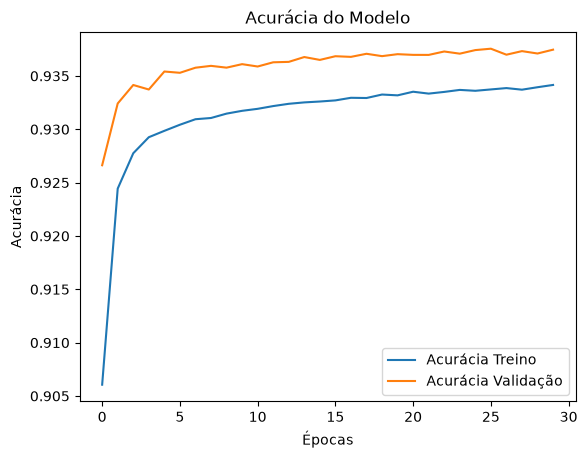

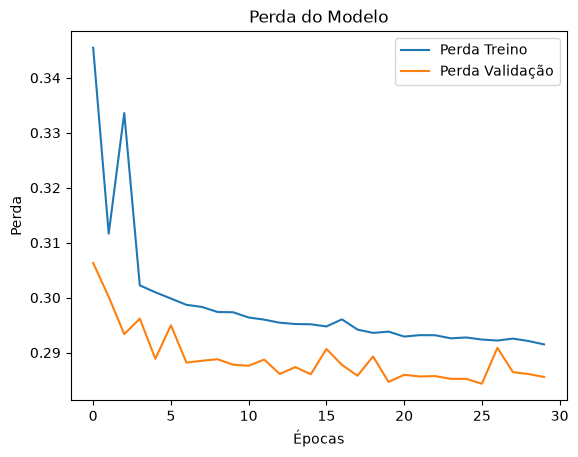

In [18]:
import matplotlib.pyplot as plt

# Plota a acurácia
plt.plot(history.history['auc'], label='Acurácia Treino')
plt.plot(history.history['val_auc'], label='Acurácia Validação')
plt.title('Acurácia do Modelo')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

# Plota a perda (loss)
plt.plot(history.history['loss'], label='Perda Treino')
plt.plot(history.history['val_loss'], label='Perda Validação')
plt.title('Perda do Modelo')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

In [19]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

3241/3241 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - auc: 0.9372 - loss: 0.2841
Test loss: 0.28408029675483704
Test accuracy: 0.9372345209121704


In [31]:
preds = model.predict(X_test)
preds = preds.flatten()

3241/3241 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [32]:
cm = confusion_matrix(y_test, preds, normalize="true")

sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [21]:
print(roc_auc_score(y_test,preds))

0.937329316603238


In [22]:
df_training.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 30 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   scaler__age                          691369 non-null  float64
 1   scaler__daily_screen_time_hours      691369 non-null  float64
 2   scaler__social_media_hours           691369 non-null  float64
 3   scaler__gaming_hours                 691369 non-null  float64
 4   scaler__work_study_hours             691369 non-null  float64
 5   scaler__sleep_hours                  691369 non-null  float64
 6   scaler__notifications_per_day        691369 non-null  float64
 7   scaler__app_opens_per_day            691369 non-null  float64
 8   scaler__weekend_screen_time          691369 non-null  float64
 9   encoder__gender_Female               691369 non-null  float64
 10  encoder__gender_Male                 691369 non-null  float64
 11  encoder__gender_Other   

In [27]:
preds_final = model.predict(df_testing)
preds_final = preds_final.flatten()

9260/9260 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


In [28]:

df_result = pd.DataFrame({"id": ids, "addicted_label":preds_final})

df_result.to_csv("submission.csv", index=False)
